In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("Cardiotocographic.csv")
df

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


The dataset is loaded sucessfully

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


df.info() shows is there any non-null values, Dtypes in the dataset

In [5]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


df.describe() provides a statistical summary of all numerical columns, including count, mean, standard deviation, minimum, quartiles, and maximum values.

In [7]:
df.shape

(2126, 14)

df.shape shows the shape of the data

In [8]:
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64
Shape after removing duplicates: (2124, 14)


Checks for missing values in the dataset and removes duplicate records to improve data quality.

In [29]:
# Detect Outliers using IQR Method

for col in df.columns:


        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

        print(f"{col}: {len(outliers)} outliers")

LB: 0 outliers
AC: 0 outliers
FM: 240 outliers
UC: 0 outliers
DL: 34 outliers
DS: 0 outliers
DP: 0 outliers
ASTV: 0 outliers
MSTV: 14 outliers
ALTV: 122 outliers
MLTV: 3 outliers
Width: 0 outliers
Tendency: 0 outliers
NSP: 0 outliers


In [12]:
for col in df.columns:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    df=df[(df[col]>=lower) & (df[col]<=upper)]

This code detects and removes outliers from each numerical column using the Interquartile Range (IQR) method. It calculates the lower and upper limits based on the IQR and retains only the values that fall within these limits. This helps improve the quality of the dataset by reducing the effect of extreme values.

In [9]:
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nMode")
print(df.mode().iloc[0])

print("\nStandard Deviation")
print(df.std(numeric_only=True))

print("\nIQR")
Q1=df.quantile(0.25,numeric_only=True)
Q3=df.quantile(0.75,numeric_only=True)
print(Q3-Q1)

Mean
LB          133.342023
AC            0.003220
FM            0.009904
UC            0.004394
DL            0.001897
DS            0.000003
DP            0.000175
ASTV         47.012459
MSTV          1.364345
ALTV         10.295650
MLTV          8.280546
Width        70.461052
Tendency      0.316672
NSP           1.304797
dtype: float64

Median
LB          133.000000
AC            0.001634
FM            0.000000
UC            0.004486
DL            0.000000
DS            0.000000
DP            0.000000
ASTV         49.000000
MSTV          1.200000
ALTV          0.000000
MLTV          7.400000
Width        67.486468
Tendency      0.000000
NSP           1.000000
dtype: float64

Mode
LB          133.0
AC            0.0
FM            0.0
UC            0.0
DL            0.0
DS            0.0
DP            0.0
ASTV         65.0
MSTV          0.5
ALTV          0.0
MLTV          0.0
Width        39.0
Tendency      0.0
NSP           1.0
Name: 0, dtype: float64

Standard Deviation
LB         

This code calculates the mean, median, mode, standard deviation, and Interquartile Range (IQR) for all numerical columns in the dataset. These statistical measures summarize the central tendency and variability of the data, helping to understand its overall distribution and spread.

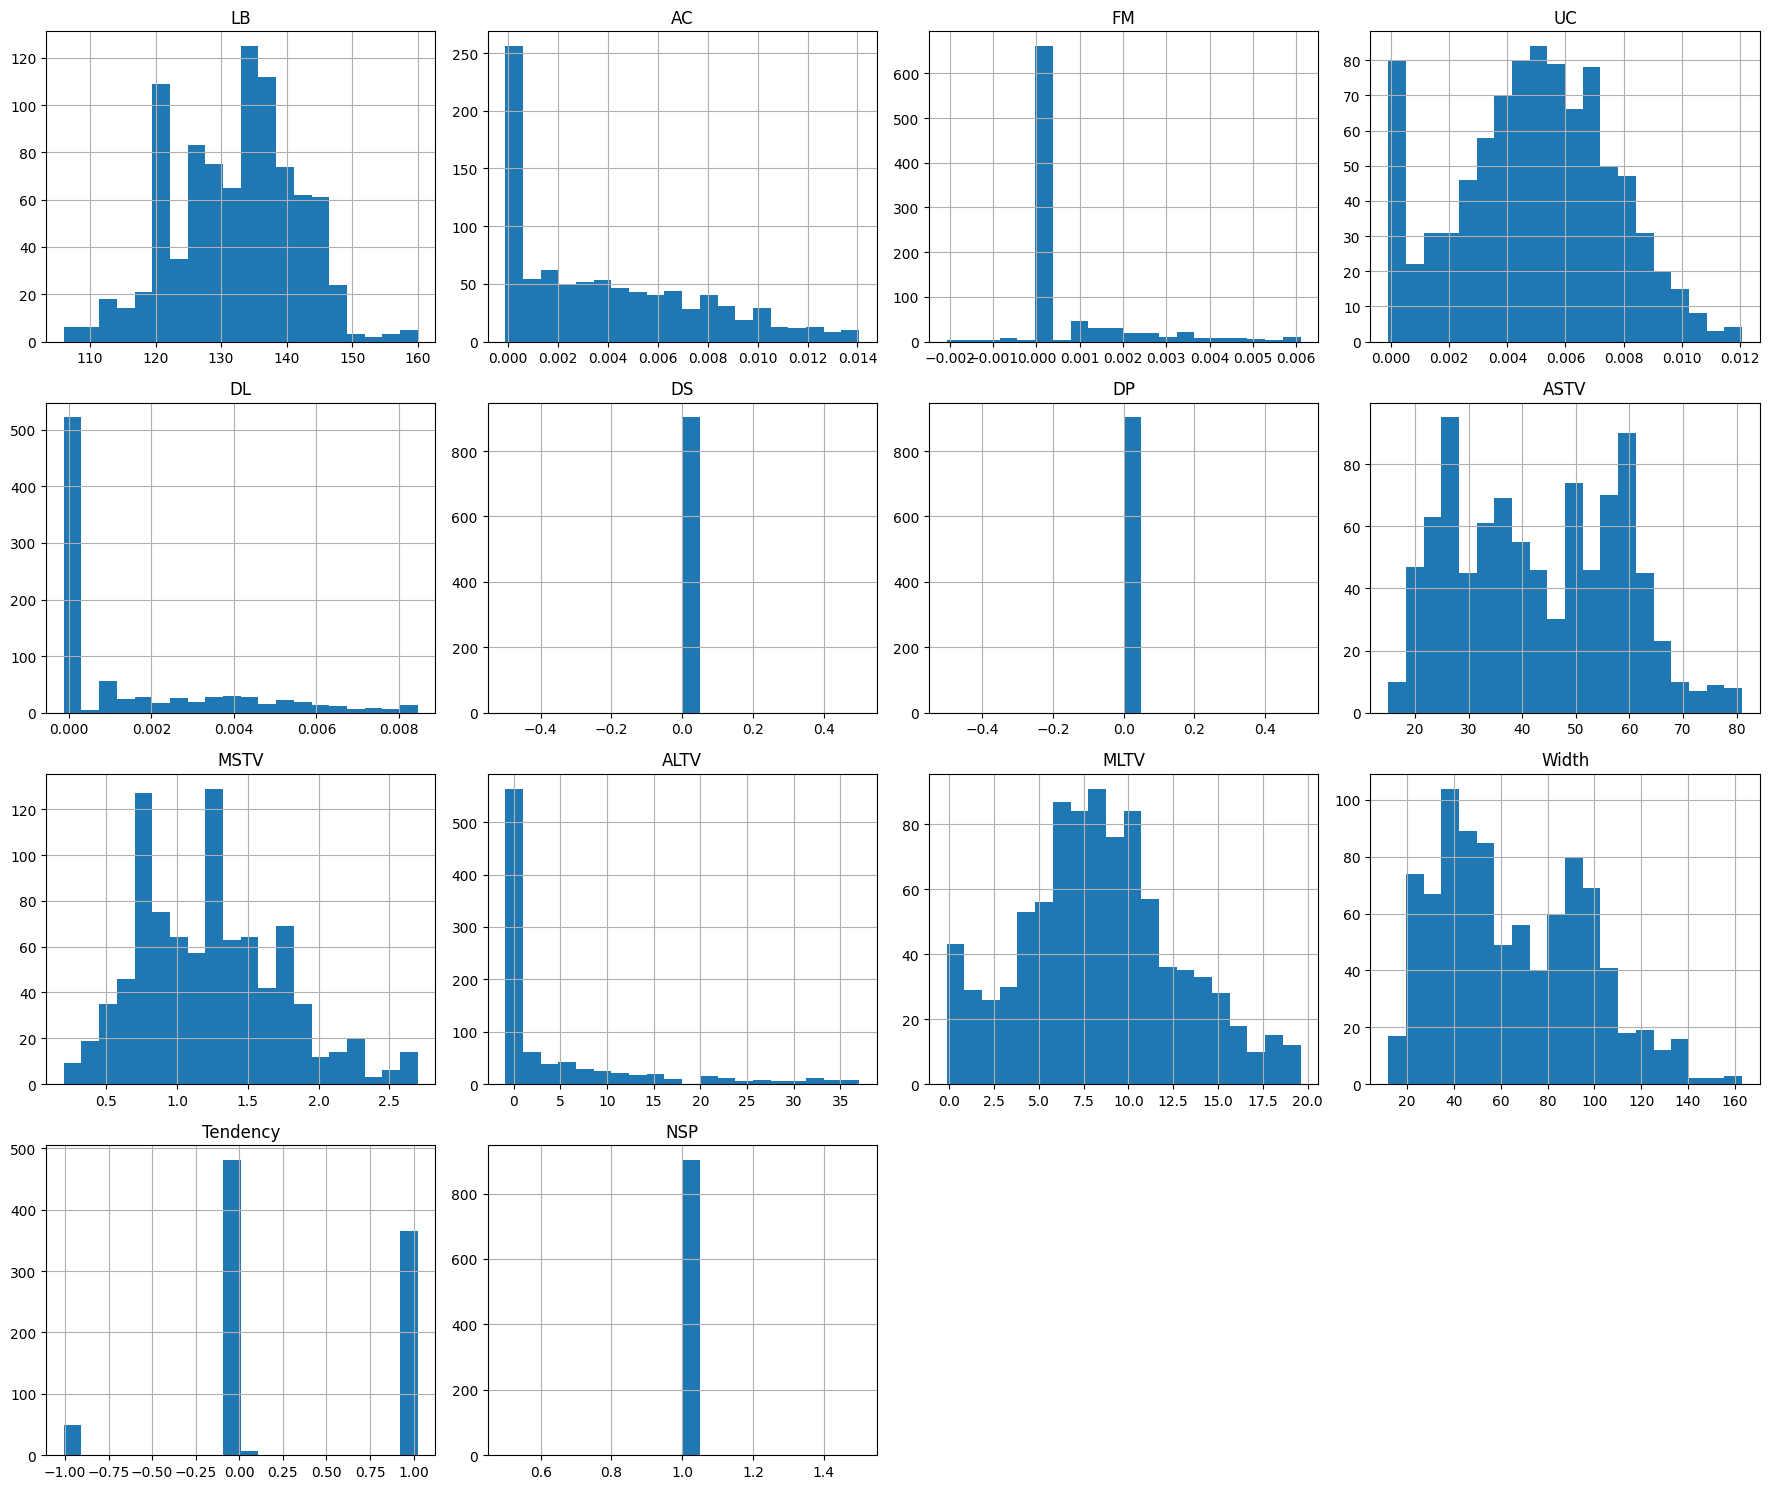

In [14]:
df.hist(figsize=(18,15),bins=20)
plt.tight_layout()
plt.show()

This code generates histograms for all numerical columns in the dataset. Histograms help visualize the distribution, frequency, and spread of each feature, making it easier to identify patterns, skewness, and potential outliers.

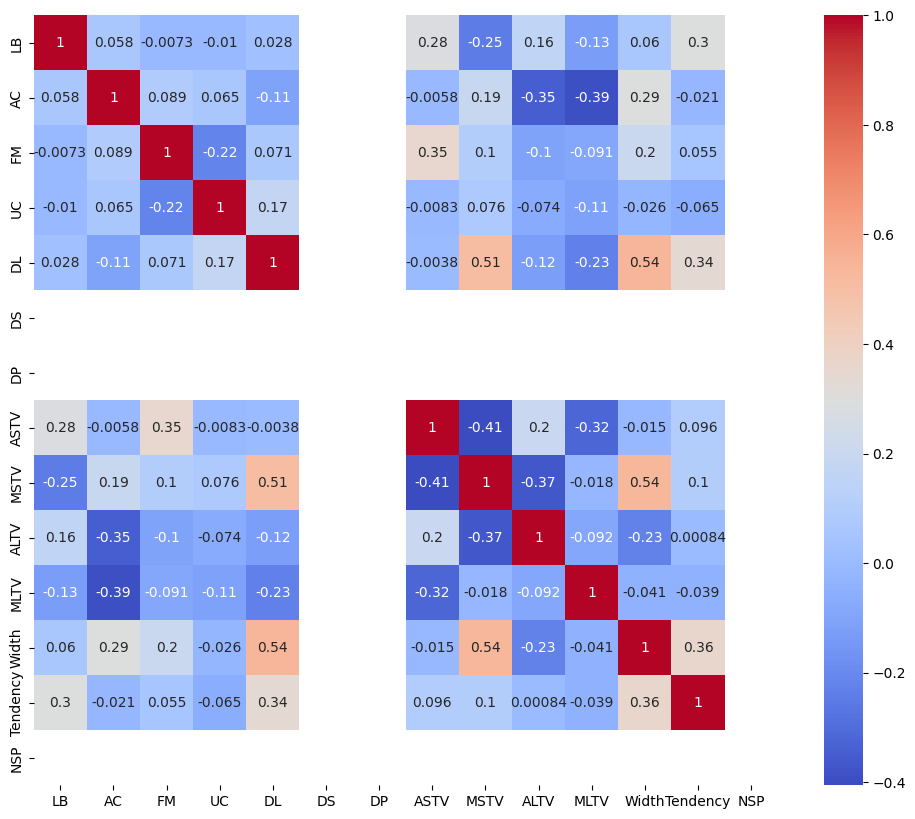

In [17]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

This code creates a correlation heatmap to visualize the relationships between all numerical variables in the dataset. The color intensity and correlation values help identify strong positive, negative, or weak correlations, making it easier to understand feature relationships.

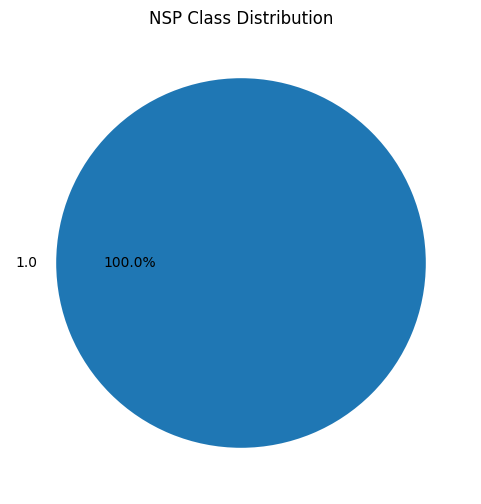

In [25]:
df['NSP'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.ylabel("")
plt.title("NSP Class Distribution")
plt.show()

This code creates a pie chart to display the distribution of the NSP classes in the dataset. It shows the percentage of each class, making it easy to understand the proportion of normal, suspect, and pathological fetal states.

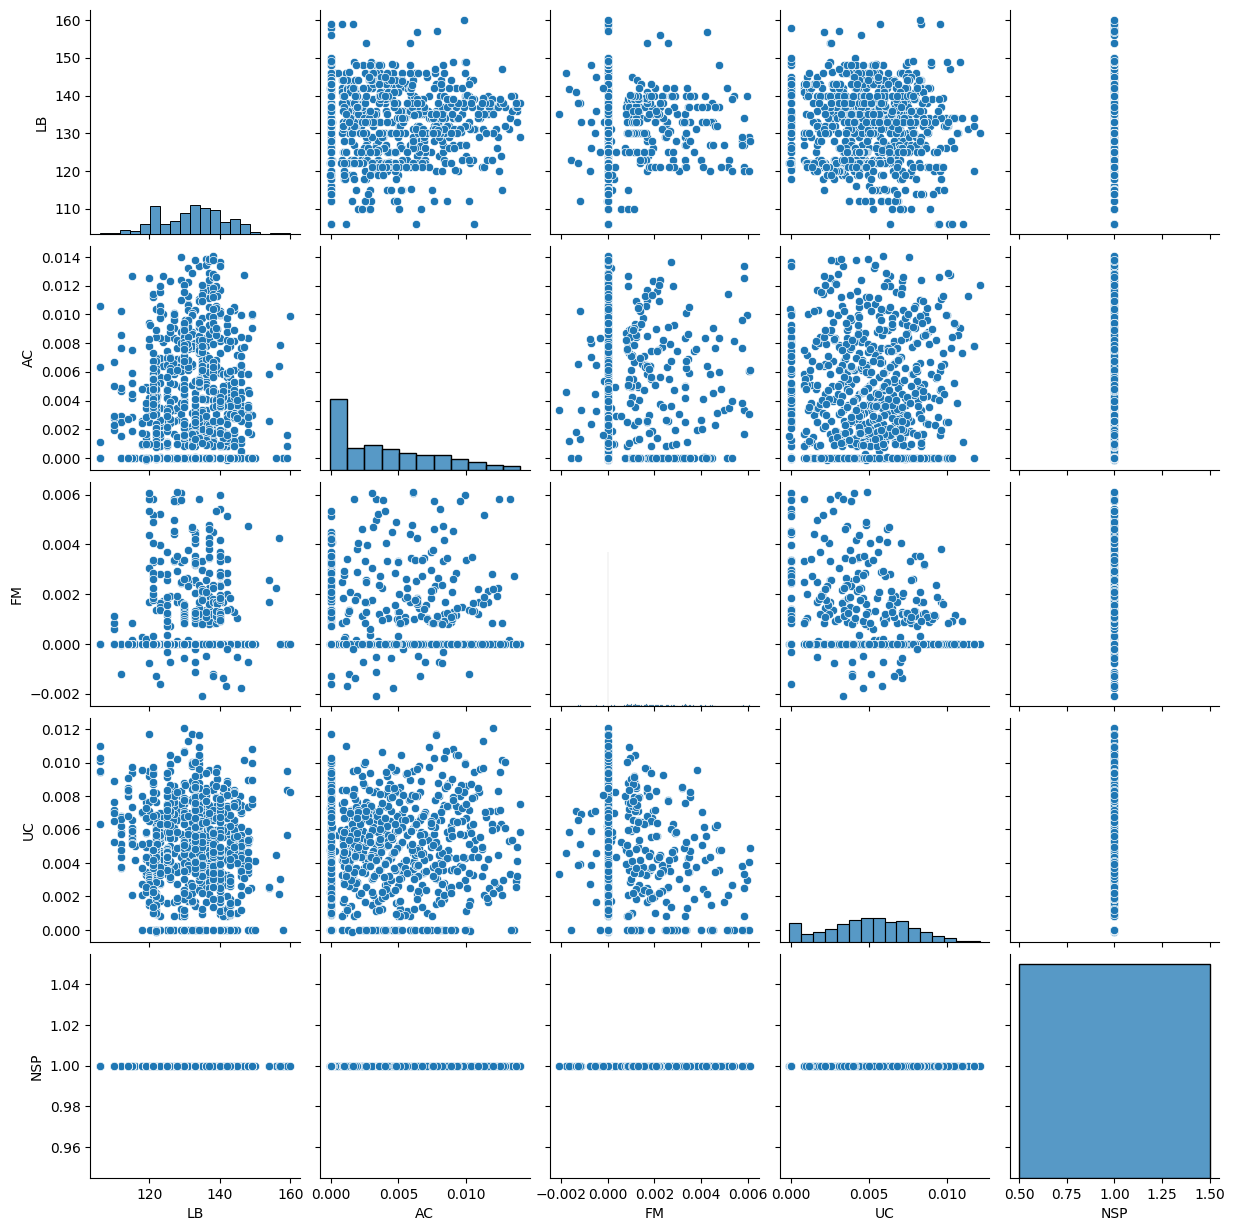

In [26]:
sns.pairplot(df[['LB','AC','FM','UC','NSP']])
plt.show()

This code generates a pair plot to visualize the relationships between the selected numerical variables (LB, AC, FM, UC) and the target variable (NSP). It helps identify correlations, trends, and the distribution of each feature through scatter plots and histograms.

In [30]:
# Correlation Matrix
correlation = df.corr()

print(correlation)

                LB        AC        FM        UC        DL  DS  DP      ASTV  \
LB        1.000000  0.057989 -0.007253 -0.009961  0.028122 NaN NaN  0.284646   
AC        0.057989  1.000000  0.088704  0.065149 -0.108561 NaN NaN -0.005799   
FM       -0.007253  0.088704  1.000000 -0.221814  0.071134 NaN NaN  0.353163   
UC       -0.009961  0.065149 -0.221814  1.000000  0.172069 NaN NaN -0.008264   
DL        0.028122 -0.108561  0.071134  0.172069  1.000000 NaN NaN -0.003819   
DS             NaN       NaN       NaN       NaN       NaN NaN NaN       NaN   
DP             NaN       NaN       NaN       NaN       NaN NaN NaN       NaN   
ASTV      0.284646 -0.005799  0.353163 -0.008264 -0.003819 NaN NaN  1.000000   
MSTV     -0.250718  0.192443  0.101042  0.076297  0.510640 NaN NaN -0.405396   
ALTV      0.159063 -0.349626 -0.104303 -0.073649 -0.120112 NaN NaN  0.195031   
MLTV     -0.130716 -0.393105 -0.090532 -0.114070 -0.233349 NaN NaN -0.317927   
Width     0.059629  0.291919  0.200971 -

This code computes the correlation matrix for all numerical variables in the dataset. It displays the correlation coefficients, which help identify the strength and direction of relationships between pairs of variables.

In [32]:
correlation=df.corr()

print(correlation['NSP'].sort_values(ascending=False))

LB         NaN
AC         NaN
FM         NaN
UC         NaN
DL         NaN
DS         NaN
DP         NaN
ASTV       NaN
MSTV       NaN
ALTV       NaN
MLTV       NaN
Width      NaN
Tendency   NaN
NSP        NaN
Name: NSP, dtype: float64


This code calculates the correlation of all numerical features with the target variable (NSP) and displays them in descending order. It helps identify which features have the strongest positive or negative relationship with the target, making them useful for feature selection and predictive analysis.

**Conclusion:**
The Exploratory Data Analysis (EDA) of the Cardiotocographic dataset was successfully completed. The dataset was cleaned by checking for missing values, removing duplicate records, and detecting outliers using the IQR method. Statistical analysis provided insights into the central tendency and variability of the numerical features. Various visualizations, including histograms, boxplots, pie charts, pair plots, and a correlation heatmap, helped understand the distribution of the data, identify outliers, and explore relationships among variables. Correlation analysis showed that several features have meaningful relationships with the target variable (NSP), indicating their importance in fetal health prediction. Since the dataset does not contain temporal information, trend analysis over time was not applicable. Overall, the dataset is well-prepared for further analysis and can be effectively used for building machine learning models for fetal health classification.